# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU4.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.


## 1. Spinograf
- **Úkol: nakreslete obrázek trajektorie bodu na spinografu pro zadané hodnoty**
    - $R$ (poloměr větší kružnice),
    - $r$ (poloměr menší kružnice),
    - $d$ (vzdálenost bodu od středu menší kružnice).
- Rozmyslete si, kolik rotací musí menší kružnice udělat, aby se bod vrátil do své původní pozice (vykreslete dráhu tak, aby byla uzavřená).
- Vyzkoušejte alespoň pro $R=10, r=3, d=1$ a $R=7, r=2, d=5$.
- Vykreslete pomocí tenké modré čáry; zvolte dostatek bodů, aby byla trajektorie plynulá.

---

### Co je to spinograf?
Jedná se o hru/výukovou pomůcku (viz https://en.wikipedia.org/wiki/Spirograph).

Pro vysvětlení trajektorie bodu na spinografu (často označovaného jako hypotrochoida, když se menší kružnice otáčí uvnitř větší kružnice) použijeme goniometrický popis polohy bodu na kružnici v závislosti na úhlu rotace. Máme jednu větší kružnici s poloměrem $R$ a jednu menší kružnici s poloměrem $r$ a chceme trasovat dráhu bodu, který je od středu menší kružnice vzdálen o vzdálenost $d$.

### Poloha středu menší kružnice

Střed menší kružnice se otáčí uvnitř větší kružnice. Poloha středu menší kružnice v závislosti na úhlu $\theta$ je dána parametrickými rovnicemi v kartézských souřadnicích:

- $X = (R - r) \cos(\theta)$
- $Y = (R - r) \sin(\theta)$

kde $\theta$ je úhel rotace středu menší kružnice v radiánech.

### Otočení menší kružnice

Menší kružnice se otočí (valí se po větší kružnici). Úhel, o který se menší kružnice otočila ve svém vlastním středu vzhledem k počátečnímu bodu, je dán délkou oblouku, který urazila:
$$\theta R$$

Pokud chceme tento oblouk vyjádřit vzhledem k úhlu otočení v radiánech, o který se otočila menší kružnice ve svém středu, převádíme zpětně z obvodu na úhel:
$$\theta \frac{R}{r}$$

Poslední dvě důležitá pozorování jsou:
- malá kružnice se otočí negativně (tedy úhel je záporný),
- malá kružnice se otočí zároveň se svým středem, tedy k úhlu otočení musíme přičíst úhel $\theta$.

Celkově máme:

$$\phi = \theta - \theta \frac{R}{r} = - \theta \frac{R-r}{r}$$

### Pozice bodu na spinografu

Nakonec sloučíme pozici středu a relativní pozici bodu ve vzdálenosti $d$ od středu menší kružnice:

- $x = X + d \cos(\phi) = (R - r) \cos(\theta) + d \cos\left(- \theta \frac{R-r}{r}\right)$
- $y = Y + d \sin(\phi) = (R - r) \sin(\theta) + d \sin\left(- \theta \frac{R-r}{r}\right)$

Pokud použijeme vlastnosti (sudost/lichost) goniometrických funkcí, můžeme tyto rovnice zjednodušit na:

$$x = (R - r) \cos(\theta) + d \cos\left(\theta \frac{R-r}{r}\right)$$
$$y = (R - r) \sin(\theta) - d \sin\left(\theta \frac{R-r}{r}\right)$$

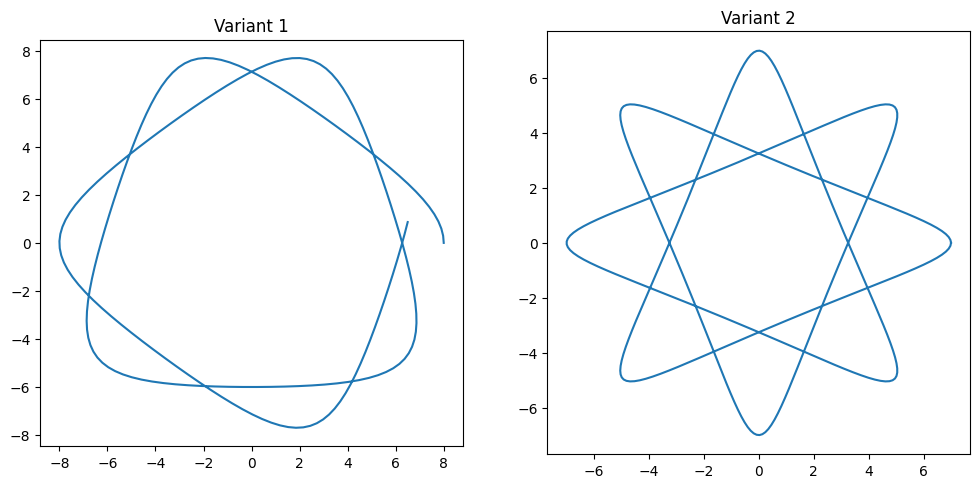

In [ ]:
import numpy as np
import matplotlib.pylab as plt
import math

# ---------------------------------------- 1.
R = 10
rolSize = 3
d = 1

l = R - rolSize
multiplier = R / rolSize - 1

rotations = int(rolSize / np.gcd(R, rolSize))
beta = np.linspace(0, rotations * 2 * math.pi, rotations * 100)
x = l * np.cos(beta) + d * np.cos(beta * multiplier)
y = l * np.sin(beta) - d * np.sin(beta * multiplier)

# ---------------------------------------- 2.
R2 = 8
r2 = 3
d2 = 2

l2 = R2 - r2
multiplier2 = R2 / r2 - 1

rotations2 = int(r2 / np.gcd(R2, r2))
beta2 = np.linspace(0, rotations2 * 2 * math.pi, rotations2 * 100)
x2 = l2 * np.cos(beta2) + d2 * np.cos(beta2 * multiplier2)
y2 = l2 * np.sin(beta2) - d2 * np.sin(beta2 * multiplier2)

# ---------------------------------------- plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(x, y)
axes[0].set_title("Variant 1")
axes[0].set_aspect('equal')

axes[1].plot(x2, y2)
axes[1].set_title("Variant 2")
axes[1].set_aspect('equal')

plt.show()

## 2. Prvočíselná spirála

**Část 1: Vykreslení „slunečnicových bodů“**

- Vykreslete tzv. slunečnicové body, tedy prvních `N` takových bodů.
- Vykreslete je tak, aby byl vzor dobře vidět (zvolte vhodnou velikost bodů).

### Co jsou to slunečnicové body?
Poloměr $r$ a úhel $\theta$ pro každý bod (číslovaný přirozenými čísly: $n=1,\ldots,N$) jsou určeny následovně:

1. Zlatý úhel $\phi$ je dán vztahem:
$$
\phi = \pi \cdot (3 - \sqrt{5})
$$

2. Poloměr $r$ je odvozen z indexu bodu $n$ jako:
$$
r = \sqrt{n}
$$

3. Úhel $\theta$ pro bod $n$ je vypočítán jako:
$$
\theta = n \cdot \phi
$$

Každý bod je poté umístěn pomocí kartézských souřadnic $(x, y)$, které jsou vypočítány jako:
$$
x = r \cdot \cos(\theta)
$$
$$
y = r \cdot \sin(\theta)
$$

**Část 2: Vykreslení prvočíselné spirály**
- Vykreslete prvočíselnou spirálu pro prvních `N` prvočísel.
- Jedná se o stejný vzor jako v případě slunečnicových bodů, ale tentokrát vykreslete pouze body, které odpovídají prvočíslům.

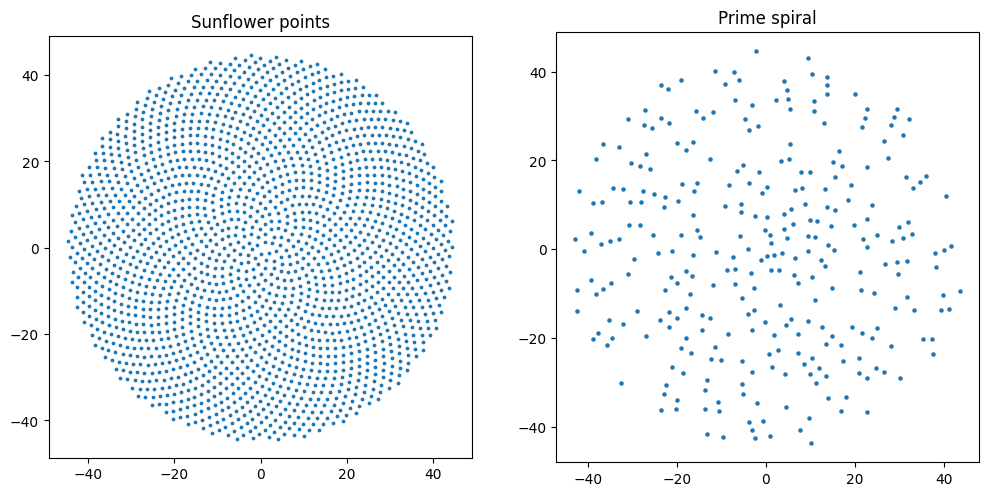

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

N = 2000
phi = math.pi * (3 - math.sqrt(5))

n = np.arange(1, N + 1)
rolSize = np.sqrt(n)
beta = n * phi

x = rolSize * np.cos(beta)
y = rolSize * np.sin(beta)

# ---------------------------------------- primes
def IsPrime(num):
    if num < 2:
        return False
    for i in range(2, int(math.sqrt(num)) + 1):
        if num % i == 0:
            return False
    return True

n = np.array([i for i in n if IsPrime(i)])

rolSize = np.sqrt(n)
beta = n * phi

x2 = rolSize * np.cos(beta)
y2 = rolSize * np.sin(beta)

# ---------------------------------------- plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(x, y, s=3)
axes[0].set_title("Sunflower points")
axes[0].set_aspect('equal')

axes[1].scatter(x2, y2, s=5)
axes[1].set_title("Prime spiral")
axes[1].set_aspect('equal')

plt.show()

## Bonusové úkoly
1. Modifikujte spinograf tak, aby se menší kružnice:
   - otáčela po vnější straně větší kružnice,
   - otáčela po rovnostranném $n$-úhelníku (trojúhelník, čtverec, šestiúhelník, ...).

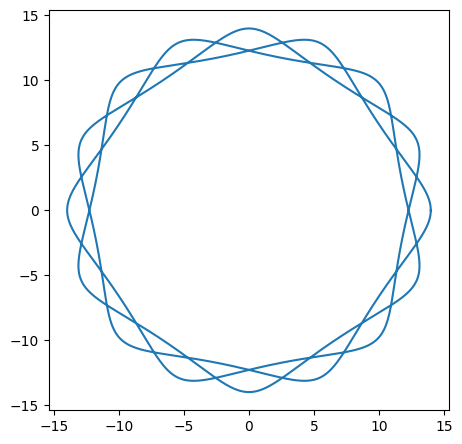

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

R = 10 
rolSize = 3
d = 1

l = R + rolSize 
multiplier = R / rolSize + 1 

rotations = int(rolSize / np.gcd(R, rolSize))
beta = np.linspace(0, rotations * 2 * math.pi, rotations * 1000) 
x = l * np.cos(beta) + d * np.cos(beta * multiplier) 
y = l * np.sin(beta) - d * np.sin(beta * multiplier) 

fig = plt.figure(figsize=(4, 4)) 

axes = fig.add_axes((0, 0, 1, 1)) 

axes.plot(x, y) 

plt.show()

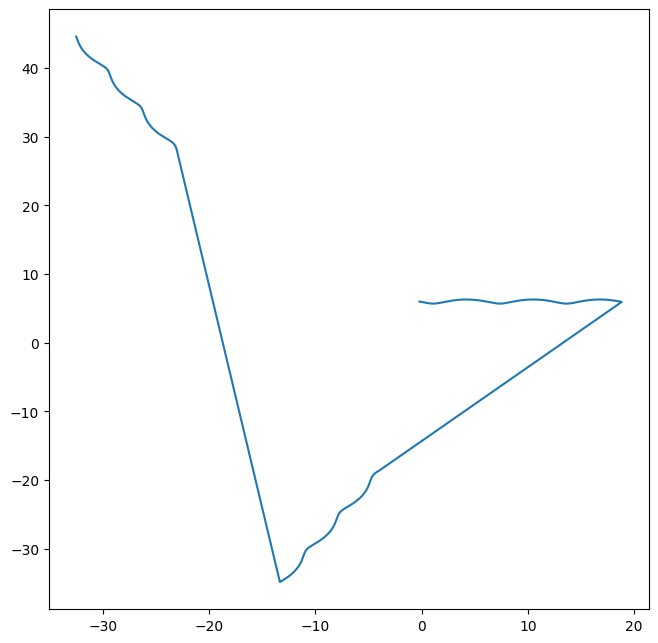

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math


precision = 1000

N = 3 # N-gon
R = 10 # size of N-gon (distance to N-gons vertices)
rolSize = 1 # size of circle
d = 0.3 # distance from center

circumcircle = 2 * math.pi * rolSize
halfAngle = math.pi / N
angle = halfAngle * 2
r = R * math.cos(halfAngle)
sideLength = 2 * R * math.sin(halfAngle) # side of ngon
expandedSideLength = 2 * (R + rolSize) * math.sin(halfAngle) # length of path of circle center on one side of ngon

bonusElements = 1
beta = np.linspace(0, expandedSideLength * N / rolSize, precision * N + bonusElements)

beta = beta[:-bonusElements] #remove last element

# coordinates for straight line rolling
x = rolSize * beta + d * np.cos(beta) - rolSize / 2
y = rolSize - d * np.sin(beta) + r


# split the sides and stack them temporarily on upper side of ngon
n = np.arange(0, N)
offset = n * rolSize
offset = offset.repeat(precision)
x -= offset
y -= offset

# rotate the split sides around ngon
rotation = n * angle
rsin = np.sin(rotation)
rcos = np.cos(rotation)
rsin = rsin.repeat(precision)
rcos = rcos.repeat(precision)


x2 =  x * rcos + y * rsin
y2 = -x * rsin + y * rcos

fig = plt.figure(figsize=(6, 6)) 

axes = fig.add_axes((0, 0, 1, 1)) 

axes.plot(x, y) 

plt.show()

